## Step 1: Set Up The Computational Environment

This cell prepares the numerical environment used throughout the notebook. Mathematically, the goal of the notebook is to compare an image $x$ with a synthesized image whose scattering covariance statistics $\Phi$ match those of $x$.

At this stage no statistics are computed yet: we simply import the tools needed to build the wavelet transform with wavelets $\psi$, evaluate $\Phi(x)$, and later solve the inverse problem that reconstructs an image from these statistics.

In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import torch

# Ensure repo root is on sys.path (so `import STL_main...` works when run from elsewhere)
REPO_DIR = os.path.abspath(os.getcwd())
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

# from STL_main.STL_2D_Kernel_Torch import STL_2D_Kernel_Torch as DataClass
from STL_main.STL_2D_FFT_Torch import STL_2D_FFT_Torch as DataClass
from STL_main.Synthesis import optimize_scattering_LBFGS
import STL_main.torch_backend as stl_tb

print("torch:", torch.__version__)

# Force CPU by default for notebooks (override by exporting `STL_DEVICE=mps` if desired)
stl_tb.set_default_device(os.environ.get("STL_DEVICE", "cpu"))
print("STL default device:", stl_tb._DEFAULT_DEVICE)

torch: 2.5.1
STL default device: cpu


## Step 2: Load The Target Image $x$

Here we define the target image $x$. This is the object whose multiscale structure we want to summarize through the scattering covariance statistics $\Phi(x)$.

The displayed image gives a visual reference: later we will compare it to a synthesized image $u$ constrained so that $\Phi(\tilde{x}) \approx \Phi(x)$.

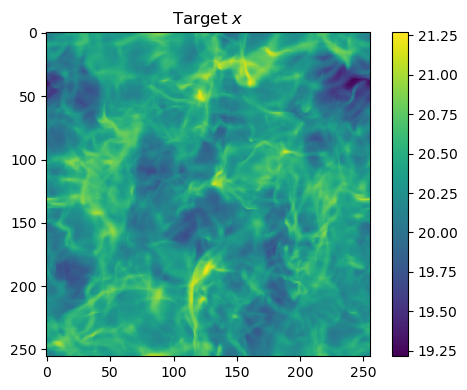

In [2]:
# Load the same target image used in the CN notebooks / user notebook
# Match `docs/user_notebook.ipynb`: add a singleton channel dim, then take im[0,0]
im = np.load("data/test/Turb_6.npy")[:, None, :, :]
x = np.stack(im[0, 0])  # (256, 256)

plt.figure(figsize=(5, 4))
plt.imshow(x)
plt.title("Target $x$")
plt.colorbar()
plt.tight_layout()

## Step 3: Build The Wavelet Representation

This cell constructs the scattering operator. The operator uses a family of wavelets $\psi$ at several scales and orientations to probe the geometry of $x$. In high-level terms, the transform analyzes filtered versions of the image such as $x \star \psi$, then combines them into the full collection of scattering covariance statistics $\Phi(x)$.

The parameters $J$ and $L$ control how many scales and directions are used, so they determine the resolution at which $\Phi$ describes the texture.

In [9]:
# Build ST operator (2D kernel backend) — match `docs/user_notebook.ipynb`
target = DataClass(x, pbc=True)
st_op = target.get_ST_op(J=6, L=4)

print("ST operator:")
print("  DT:", st_op.DT)
print("  J:", st_op.J)
print("  L:", st_op.L)

ST operator:
  DT: Planar2D_FFT_torch
  J: 6
  L: 4


## Step 4: Solve The Synthesis Problem

This is the core inverse problem of the notebook. We seek an image $u$ such that its scattering covariance statistics match those of the target image: $\Phi(u) \approx \Phi(x)$.

The optimization starts from an initial guess and updates $u$ so as to reduce a loss measuring the discrepancy between the two collections of statistics. Because $\Phi$ is built from wavelet responses involving $\psi$, the reconstruction is not pixel-by-pixel fitting; instead, it tries to reproduce the multiscale organization encoded by the scattering model.

In [10]:
# Run synthesis: find $u$ so that Phi(u) matches Phi(x)
compute_cross_matrix = None

u1, histo1 = optimize_scattering_LBFGS(
    target=target,
    st_op_target=st_op,
    st_op_running=st_op,
    pbc_running=True,
    compute_cross_matrix=compute_cross_matrix,
    nbatch=1,
    max_iter=100,
    lr=1.3,
    history_size=50,
    print_iter=10,
    verbose=True,
    seed=23,
)

Running synthesis on device cpu dtype torch.float64
Initial shape for u: (1, 1, 256, 256)
Synthesis on 3970 ST coefficients
[LBFGS] inner iter 10, loss = 5.335451e+01
[LBFGS] inner iter 20, loss = 2.603610e+00
[LBFGS] inner iter 30, loss = 2.130481e-01
[LBFGS] inner iter 40, loss = 1.228473e-01
[LBFGS] inner iter 50, loss = 7.174688e-02
[LBFGS] inner iter 60, loss = 2.425927e-02
[LBFGS] inner iter 70, loss = 1.333742e-02
[LBFGS] inner iter 80, loss = 9.598856e-03
[LBFGS] inner iter 90, loss = 7.740350e-03
[LBFGS] inner iter 100, loss = 6.577617e-03
[LBFGS] inner iter 110, loss = 5.497850e-03
115 iterations of synthesis done with nbatch=1 and 3970 ST coefficients
Execution time: 15.685 s


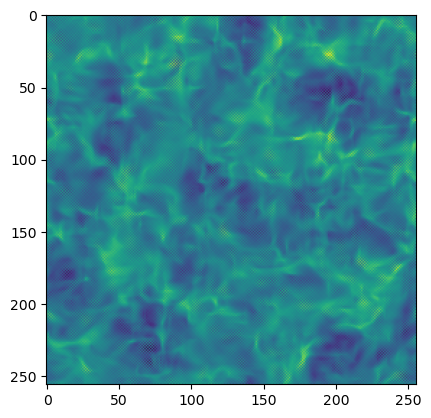

In [12]:
plt.imshow(u1)

## Step 5: Extend The Model To Multiple Channels

Now the target has several channels, which we denote by $x_c$. The statistics $\Phi$ are then computed not only within each channel, but also across selected channel pairs.

The cross-statistics matrix specifies which inter-channel covariances are included. Conceptually, this enriches $\Phi$ so that the synthesis captures both the geometry inside each channel and the dependencies between channels, again through wavelet responses built from $\psi$.

In [5]:
# --- Multi-channel synthesis (following `docs/user_notebook.ipynb`) ---

# Build a 2-channel target from the same base image
target_mc_np = np.stack([
    im[0, 0],
    (im[0, 0] - im[0, 0].mean(keepdims=True)) ** 2,
])
target_mc_np -= target_mc_np.mean(axis=(1, 2), keepdims=True)
print("target_mc_np shape:", target_mc_np.shape)

target_mc = DataClass(target_mc_np, pbc=True)
st_op_mc = target_mc.get_ST_op()

compute_cross_matrix_mc = torch.tensor([[1, 1], [0, 1]], dtype=torch.bool)

u_mc, histo_mc = optimize_scattering_LBFGS(
    target=target_mc,
    st_op_target=st_op_mc,
    st_op_running=st_op_mc,
    pbc_running=True,
    compute_cross_matrix=compute_cross_matrix_mc,
    nbatch=4,
    max_iter=50,
    lr=1.0,
    history_size=50,
    print_iter=10,
    verbose=True,
    seed=26,
)


target_mc_np shape: (2, 256, 256)
Running synthesis on device cpu dtype torch.float64
Initial shape for u: (4, 2, 256, 256)
Synthesis on 15804 ST coefficients


/Users/tsouros/Desktop/Projects/STL-Dev/STL_main/STL_2D_FFT_Torch.py:972: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at /Users/runner/miniforge3/conda-bld/libtorch_1744320346501/work/aten/src/ATen/native/Copy.cpp:308.)
  output[:, c1, c2, ...] = self.cov(


[LBFGS] inner iter 10, loss = 2.625268e+02
[LBFGS] inner iter 20, loss = 6.477977e+00
[LBFGS] inner iter 30, loss = 7.961483e-01
[LBFGS] inner iter 40, loss = 3.076420e-01
[LBFGS] inner iter 50, loss = 1.574258e-01
58 iterations of synthesis done with nbatch=4 and 15804 ST coefficients
Execution time: 122.821 s


## Step 6: Compare Multi-Channel Targets And Syntheses

This visualization compares each target channel $x_c$ with the corresponding synthesized channel $u_c$. The point is not exact pixel recovery, but agreement of the statistical descriptors $\Phi(u)$ and $\Phi(x)$.

Using the same color scale for each target/synthesis pair makes it easier to judge whether the synthesized channels reproduce the same large-scale amplitudes, contrasts, and texture organization suggested by the wavelet-based statistics.

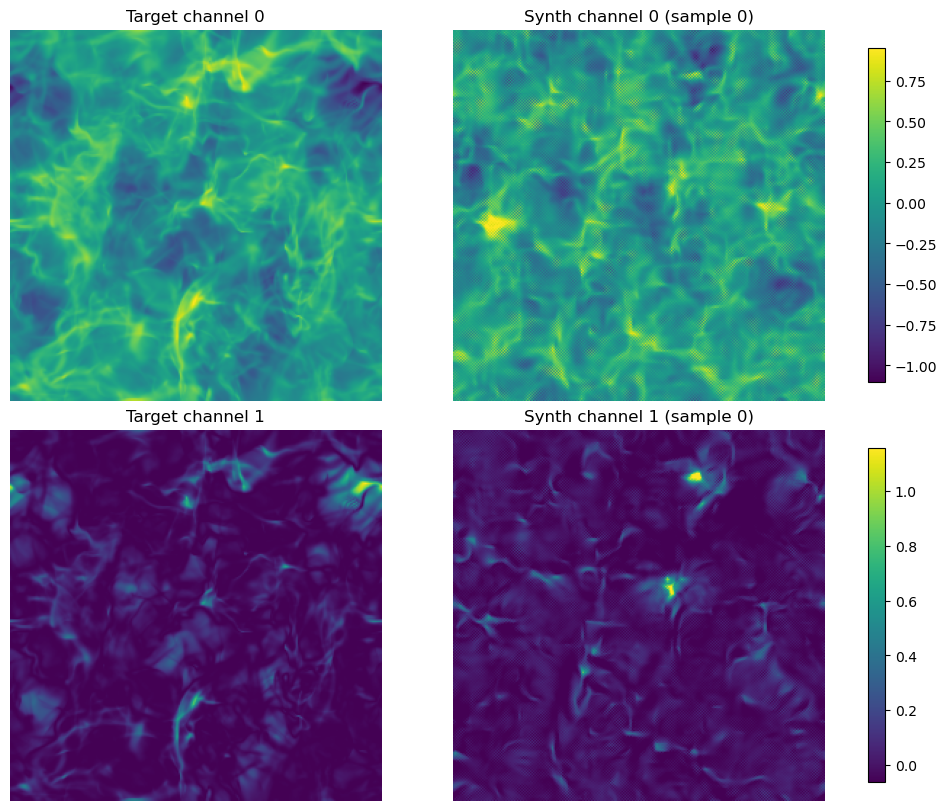

In [6]:
# Plot target vs synthesized for each channel (shared colorbar per channel)
# NOTE: with nbatch=4, u_mc has shape (4, 2, 256, 256). Pick one sample to plot.
batch_idx = 0  # change if you want a different synthesized sample

fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

for c in range(2):
    t = target_mc.array[c].detach().cpu().numpy()      # (256, 256)
    u = u_mc[batch_idx, c].detach().cpu().numpy()      # (256, 256)

    vmin, vmax = np.nanmin(t), np.nanmax(t)

    axes[c, 0].imshow(t, vmin=vmin, vmax=vmax)
    axes[c, 0].set_title(f"Target channel {c}")
    axes[c, 0].axis("off")

    im = axes[c, 1].imshow(u, vmin=vmin, vmax=vmax)
    axes[c, 1].set_title(f"Synth channel {c} (sample {batch_idx})")
    axes[c, 1].axis("off")

    fig.colorbar(im, ax=axes[c, :], shrink=0.9)

plt.show()


## Step 7: Compare The Single-Channel Result

This figure places the original image $x$ next to the synthesized image $u$ in the mono-channel setting. If the optimization has succeeded, the two images may differ pointwise, but they should share the same qualitative multiscale structure because $\Phi(u)$ has been matched to $\Phi(x)$.

This is a standard feature of texture synthesis: the constraint is statistical and wavelet-based, not exact reconstruction of every pixel.

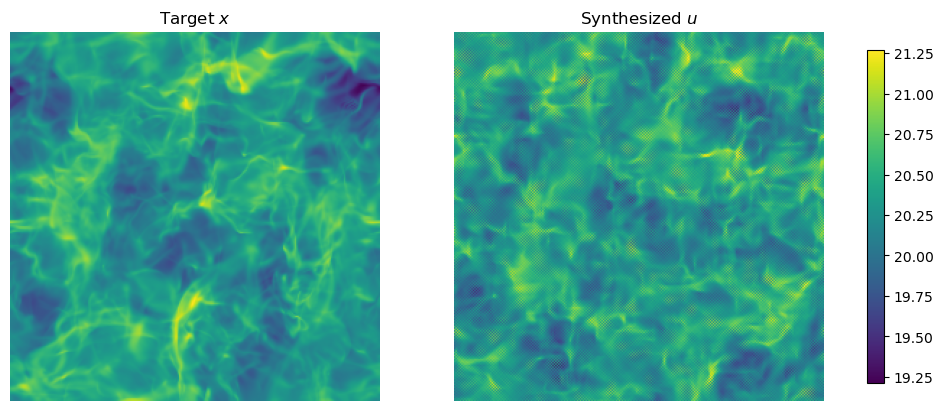

In [13]:
# Plot target and synthesized with the same colorbar
x_np = target.array.detach().cpu().numpy()
u_np = u1.detach().cpu().numpy()

vmin = np.nanmin(x_np)
vmax = np.nanmax(x_np)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
im0 = axes[0].imshow(x_np, vmin=vmin, vmax=vmax)
axes[0].set_title("Target $x$")
axes[0].axis("off")

im1 = axes[1].imshow(u_np, vmin=vmin, vmax=vmax)
axes[1].set_title("Synthesized $u$")
axes[1].axis("off")

fig.colorbar(im1, ax=axes, shrink=0.9)
plt.show()

## Step 8: Monitor Convergence Of The Optimization

The loss history shows how the discrepancy between $\Phi(u)$ and $\Phi(x)$ evolves during optimization. A decreasing curve indicates that the synthesized image is moving toward the target in the space of scattering covariance statistics.

Plotting the loss on a logarithmic scale is useful because these discrepancies often decrease over several orders of magnitude.

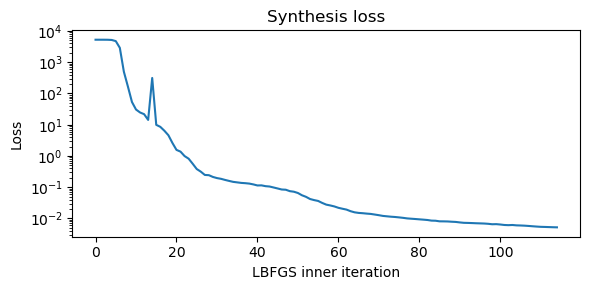

In [8]:
# Loss history
plt.figure(figsize=(6, 3))
plt.plot(histo1)
plt.yscale("log")
plt.xlabel("LBFGS inner iteration")
plt.ylabel("Loss")
plt.title("Synthesis loss")
plt.tight_layout()
plt.show()

## Additional Notes

This empty code cell can be used for further experiments. For example, one could inspect individual components of $\Phi(x)$, vary the wavelet family $\psi$, or test how the synthesis changes when the optimization parameters are modified.

## Further Exploration

This second empty code cell is a sandbox for extensions. A natural next step would be to compare several synthesized images $u^{(k)}$ having similar $\Phi$ values, illustrating that many different images can share the same high-level scattering covariance statistics.